# Modelado y evaluación temporal

La ejecución completa está en `run_pipeline.py` y los módulos `src/`. Este notebook revisa sus salidas y recalcula las métricas del dashboard para comprobar que coinciden con la evaluación. Para entrenar de nuevo: `python run_pipeline.py`.

El modelo se elige con tres bloques de validación. El último bloque, 31/07/2017 a 15/08/2017, es un test interno independiente. El test oficial de Kaggle no tiene etiquetas y no produce una puntuación local.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
from IPython.display import display, Image
root = Path.cwd()
if not (root / "outputs").exists():
    root = root.parent


In [2]:
metadata = json.loads((root / "outputs/run_metadata.json").read_text())
selection = json.loads((root / "outputs/selection.json").read_text())
display(selection)
display(metadata["config"])
print("Variables:", metadata["features"])

Variables: ['store_nbr', 'family_code', 'series_code', 'city_code', 'state_code', 'type_code', 'cluster', 'day_of_week', 'month', 'day_index', 'year_sin', 'year_cos', 'is_payday', 'is_holiday', 'is_event', 'is_work_day', 'promotion_log', 'is_promotion', 'lag_1', 'lag_7', 'lag_14', 'lag_28', 'mean_7', 'mean_28', 'std_28', 'weekday_mean_4', 'missing_lags']


{'selected_candidate': 'lightgbm_63',
 'selection_cutoffs': ['2017-06-12', '2017-06-28', '2017-07-14'],
 'minimum_mae_improvement': 0.05,
 'rule': 'menor MAE medio, mejora >=5% global y mejora en cada bloque de validación',
 'holdout_used_for_selection': False}

{'horizon': 16,
 'train_window_days': 730,
 'validation_cutoffs': ['2017-06-12', '2017-06-28', '2017-07-14'],
 'holdout_cutoff': '2017-07-30',
 'ridge_alpha': 30.0,
 'lightgbm_candidates': {'lightgbm_31': {'num_leaves': 31,
   'n_estimators': 300},
  'lightgbm_63': {'num_leaves': 63, 'n_estimators': 400}},
 'learning_rate': 0.05,
 'min_child_samples': 120,
 'n_jobs': 4,
 'random_state': 42,
 'minimum_mae_improvement': 0.05}

## Comparación en los tres bloques de validación

Baseline y modelos predicen recursivamente bajo la misma restricción. El baseline no puede consultar ventas reales del horizonte a partir del día 8. Ridge sirve como alternativa lineal y las dos configuraciones de LightGBM permiten una comparación pequeña y reproducible.

In [3]:
folds = pd.read_csv(root / "outputs/metrics_by_fold.csv")
display(folds.loc[folds["role"].eq("validacion")].pivot(index="cutoff", columns="model", values="mae").round(3))
assert selection["holdout_used_for_selection"] is False

model,baseline_semanal,lightgbm_31,lightgbm_63,ridge
cutoff,,,,
2017-06-12,77.251,60.499,59.111,83.548
2017-06-28,78.824,60.693,58.542,79.067
2017-07-14,67.294,59.772,58.317,71.976


## Resultado del test interno

Estas métricas no han intervenido en la selección. MAE se expresa en la escala de sales. WAPE es la suma del error absoluto dividida entre las ventas totales. RMSLE complementa la comparación y ayuda a ver diferencias en la escala logarítmica.

In [4]:
metrics = pd.read_csv(root / "outputs/metrics_summary.csv")
test = metrics.loc[metrics["role"].eq("test_interno")].set_index("model")
display(test[["n", "mae", "rmse", "wape", "rmsle", "bias_pct"]].round(4))
winner = metadata["selected_candidate"]
improvement = 1 - test.loc[winner, "mae"] / test.loc["baseline_semanal", "mae"]
print(f"Mejora MAE del modelo elegido: {improvement:.2%}")

Mejora MAE del modelo elegido: 21.43%


,n,mae,rmse,wape,rmsle,bias_pct
model,,,,,,
baseline_semanal,28512,96.5354,348.3817,0.2067,0.6170,0.0041
lightgbm_31,28512,79.0765,282.7316,0.1693,0.4322,-0.0082
lightgbm_63,28512,75.8495,275.9950,0.1624,0.4265,-0.0060
ridge,28512,94.5477,282.4526,0.2024,1.5113,0.0515


## Comprobación de las métricas desde los CSV de Power BI

El CSV conserva el detalle de errores en precisión de 64 bits antes de redondearlo para exportar. Recalculo las métricas con las mismas filas, sin promediar porcentajes por tienda o familia.

In [5]:
valid = pd.read_csv(root / "powerbi/data/validacion.csv")
rows = []
alias = {"baseline_semanal":"baseline_semanal", "ridge":"ridge", "lightgbm":metadata["lightgbm_dashboard_candidate"]}
for model, group in valid.groupby("model"):
    error = group["prediction"] - group["sales"]
    mae = error.abs().mean()
    rmse = np.sqrt((error**2).mean())
    wape = error.abs().sum() / group["sales"].sum()
    expected = test.loc[alias[model]]
    assert np.isclose(mae, expected["mae"], rtol=1e-7)
    assert np.isclose(rmse, expected["rmse"], rtol=1e-7)
    assert np.isclose(wape, expected["wape"], rtol=1e-7)
    rows.append({"model":model, "mae":mae, "rmse":rmse, "wape":wape})
display(pd.DataFrame(rows).round(5))

,model,mae,rmse,wape
0,baseline_semanal,96.53539,348.38175,0.20665
1,lightgbm,75.84951,275.99504,0.16237
2,ridge,94.54772,282.45260,0.20240


## Comprobación del baseline a partir del octavo día

Las predicciones de los días 8-14 repiten las del 1-7. Esto es lo que corresponde a un baseline semanal recursivo, sin abrir las etiquetas reales del bloque.

In [6]:
baseline = valid.loc[valid["model"].eq("baseline_semanal")]
pivot = baseline.pivot(index=["store_nbr","family"], columns="horizon_day", values="prediction")
np.testing.assert_allclose(pivot[list(range(8,15))].to_numpy(), pivot[list(range(1,8))].to_numpy())
print("Baseline recursivo comprobado en las 1.782 series.")

Baseline recursivo comprobado en las 1.782 series.


## Error por horizonte y familia

En este test el error no crece de forma uniforme con el horizonte. Hay picos en fechas concretas. La recursión puede acumular error, pero no se puede atribuir toda la curva únicamente a ese efecto.

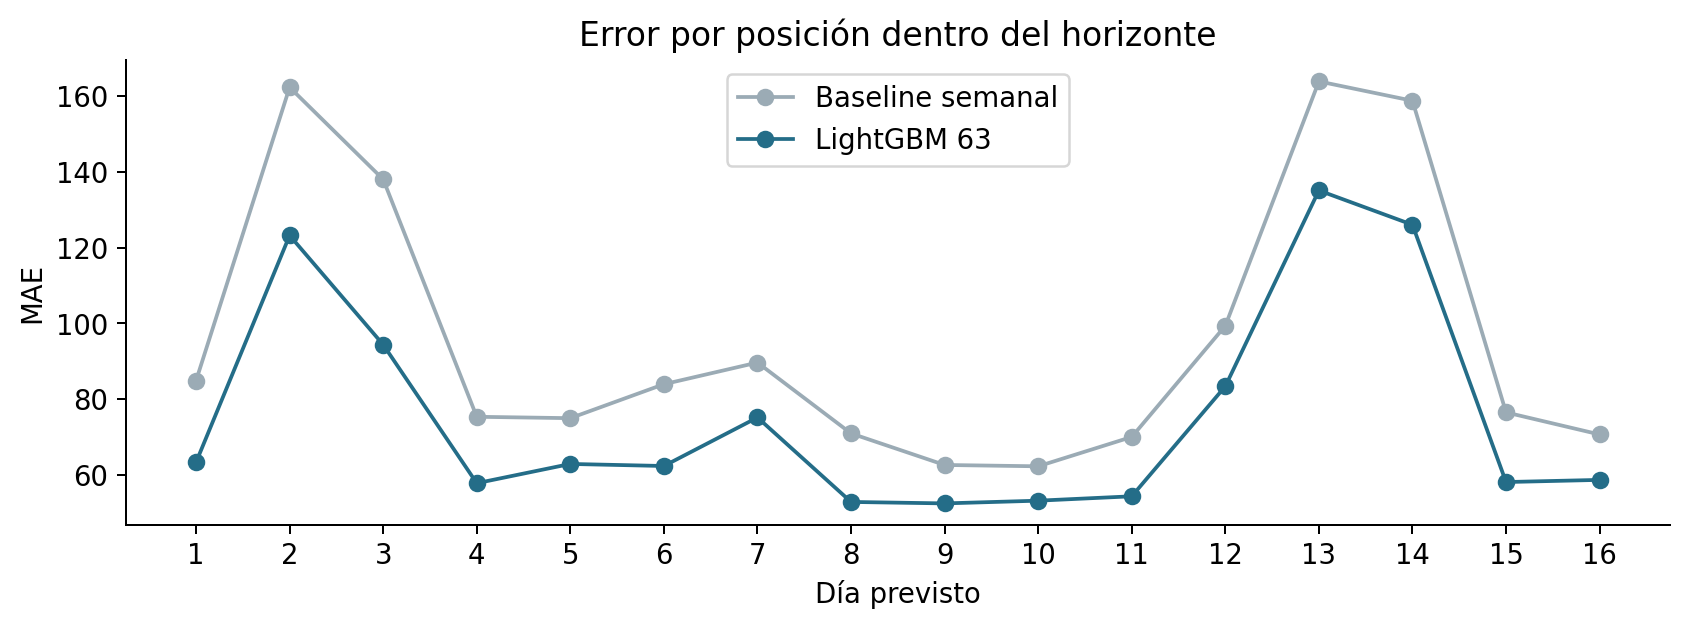

,role,model,family,n,mae,rmse,wape,rmsle,bias_pct
78,test_interno,lightgbm_63,GROCERY I,864,674.052,1015.981,0.146,0.198,-0.042
69,test_interno,lightgbm_63,BEVERAGES,864,628.670,963.543,0.181,0.251,0.009
73,test_interno,lightgbm_63,CLEANING,864,307.583,522.497,0.249,0.318,0.034
96,test_interno,lightgbm_63,PRODUCE,864,245.606,424.576,0.107,0.154,0.026
74,test_interno,lightgbm_63,DAIRY,864,92.448,141.871,0.111,0.154,0.041
84,test_interno,lightgbm_63,HOME CARE,864,65.095,100.119,0.223,0.254,0.107
71,test_interno,lightgbm_63,BREAD/BAKERY,864,64.559,103.838,0.119,0.183,-0.003
91,test_interno,lightgbm_63,PERSONAL CARE,864,55.796,95.498,0.174,0.230,-0.034


In [7]:
display(Image(filename=str(root / "docs/figures/06_horizon_error.png")))
segments = pd.read_csv(root / "outputs/metrics_by_family.csv")
display(segments.loc[segments["role"].eq("test_interno") & segments["model"].eq(winner)].sort_values("mae",ascending=False).head(8).round(3))

## Forecast final y límites

Las 28.512 predicciones finales corresponden al 16-31 de agosto de 2017. No hay ventas reales de ese bloque para evaluarlas aquí. Las métricas de calidad mostradas en Power BI corresponden al test interno, con sus fechas visibles. No calculo demanda insatisfecha ni ahorro económico porque no hay stock, precios o costes.

,id,sales
0,3000888,3.944102
1,3000889,0.000000
2,3000890,4.968716
3,3000891,2232.675049
4,3000892,0.000000


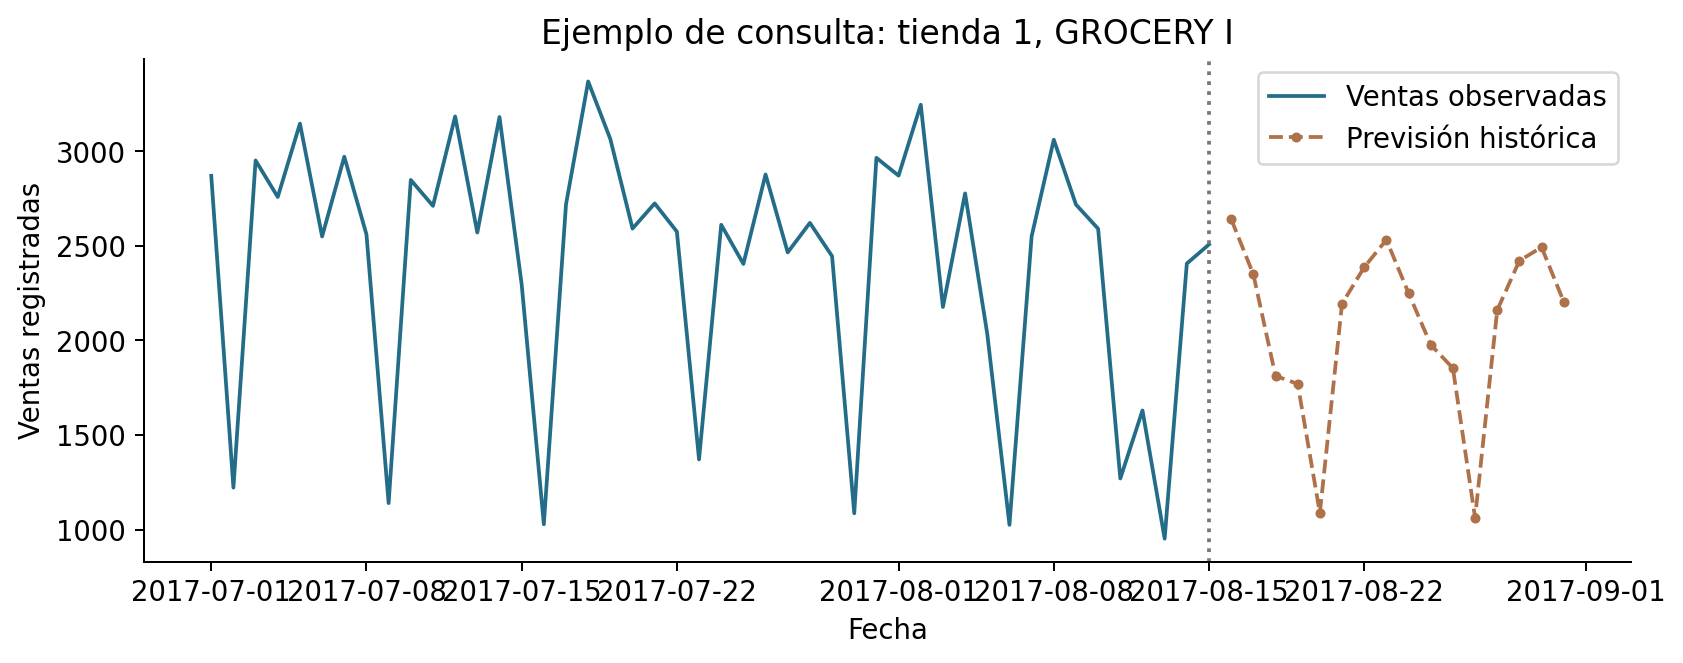

In [8]:
forecast = pd.read_csv(root / "powerbi/data/predicciones.csv")
submission = pd.read_csv(root / "outputs/submission.csv")
assert forecast.groupby("model").size().eq(28512).all()
assert len(submission) == 28512 and submission["id"].is_unique
assert submission["sales"].ge(0).all() and np.isfinite(submission["sales"]).all()
display(submission.head())
display(Image(filename=str(root / "docs/figures/07_forecast_example.png")))